# 04 – EDA: Competition Analysis

### Purpose
Analyse der Wettbewerbsdynamik in EU-Vergaben.

### Steps
1. Distribution of NUMBER_OFFERS / OFFERS_BIN
- failed tenders
- low competition
- medium
- high

2. Competition by country
- DE vs EU
- top 10 countries with lowest competition
- maps (optional)

3. Competition by CPV division
- which sectors have the most failed tenders
- which sectors attract many bidders

4. Competition by procedure type
- open vs restricted vs negotiated
- accelerated procedures
- electronic auctions


--------------------
#### Imports & Setup & Dataset
-------------------

In [2]:
# ---------------------------------------------------------
# Import moduls
# ---------------------------------------------------------

# import standard modules
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

import sys
from pathlib import Path

In [3]:
# ---------------------------------------------------------
# Setup style
# ---------------------------------------------------------

# show all columns
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

# visualisation settings
pd.set_option('display.float_format', '{:,.2f}'.format)

# seaborn style
sns.set_theme(style="whitegrid")

In [4]:
# ---------------------------------------------------------
# Load scripts
# ----------------------------------------------------------

%load_ext autoreload
%autoreload 2

from pathlib import Path
import sys

# found min directory
PROJECT_ROOT = Path("..").resolve()

# maindirectory sys.path
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# import function from script
from my_scripts.visualization import (
    plot_offers_bin_distribution,
    plot_failed_rate_by_country,
    plot_failed_rate_by_cpv_division,
    plot_failed_rate_by_procedure,
    plot_failed_rate_over_time,
    visual_de
)
from my_scripts.eda import overview

In [5]:
# ---------------------------------------------------------
# Load Dataset
# ---------------------------------------------------------

df = pd.read_pickle("../data/dataset_fe.pkl")
df_de = pd.read_pickle("../data/dataset_de_fe.pkl")

# quick overview
overview(df)

,dtype,total,missing_n,missing_%,uniques_n,uniques
YEAR,int64,4039906,0,0.00,9,"[2008, 2009, 2010, 2011, 2012, 2013, 2014, 201..."
ID_TYPE,int64,4039906,0,0.00,7,"[3, 6, 18, 25, 21, 23, 22]"
XSD_VERSION,str,4039906,0,0.00,7,"[D205, D206, D207, R207.S3, R208.S1, R208.S2, ..."
CANCELLED,int64,4039906,0,0.00,2,"[0, 1]"
CORRECTIONS,int64,4039906,0,0.00,10,"[0, 1, 2, 3, 5, 4, 84, 7, 8, 6]"
ISO_COUNTRY_CODE,str,4039906,0,0.00,33,"[DE, FR, ES, SE, PL, IT, HU, CY, UK, RO, PT, N..."
CAE_TYPE,str,4039906,0,0.00,10,"[8, 3, 1, 6, R, N, 4, 5A, 5, Z]"
B_AWARDED_BY_CENTRAL_BODY,str,4039906,0,0.00,3,"[Unknown, Y, N]"
TYPE_OF_CONTRACT,str,4039906,0,0.00,3,"[W, U, S]"
TAL_LOCATION_NUTS,str,4039906,0,0.00,9310,"[DED31, DE913, Unknown, DE13A, ES3, FR91, FR52..."


--------------
## Competition Analyse - EU

--------------

In [6]:
# competition overview

df[["IS_FAILED_TENDER", "IS_LOW_COMPETITION", "OFFERS_BIN"]].describe()


,IS_FAILED_TENDER,IS_LOW_COMPETITION
count,"4,039,906.00","4,039,906.00"
mean,0.21,0.14
std,0.41,0.35
min,0.00,0.00
25%,0.00,0.00
50%,0.00,0.00
75%,0.00,0.00
max,1.00,1.00


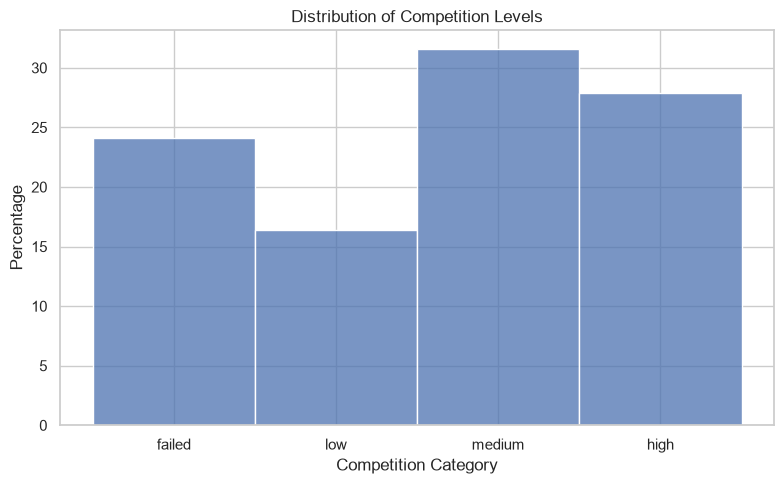

In [7]:
# distribution of competition levels          
plot_offers_bin_distribution(df, save=True)


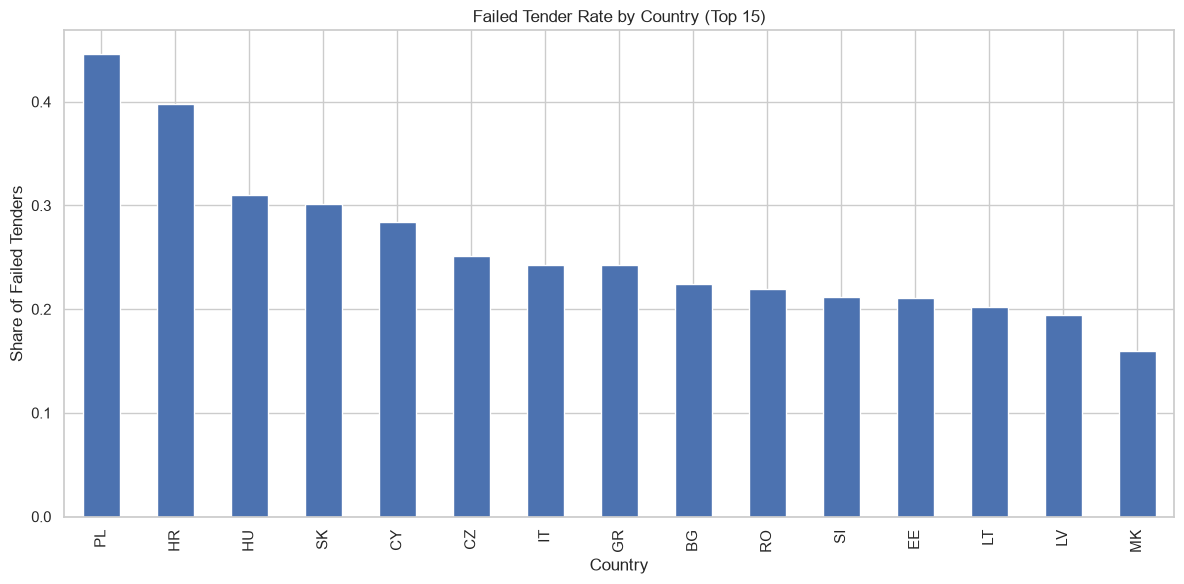

In [8]:
# competition by country

plot_failed_rate_by_country(df, save=True)

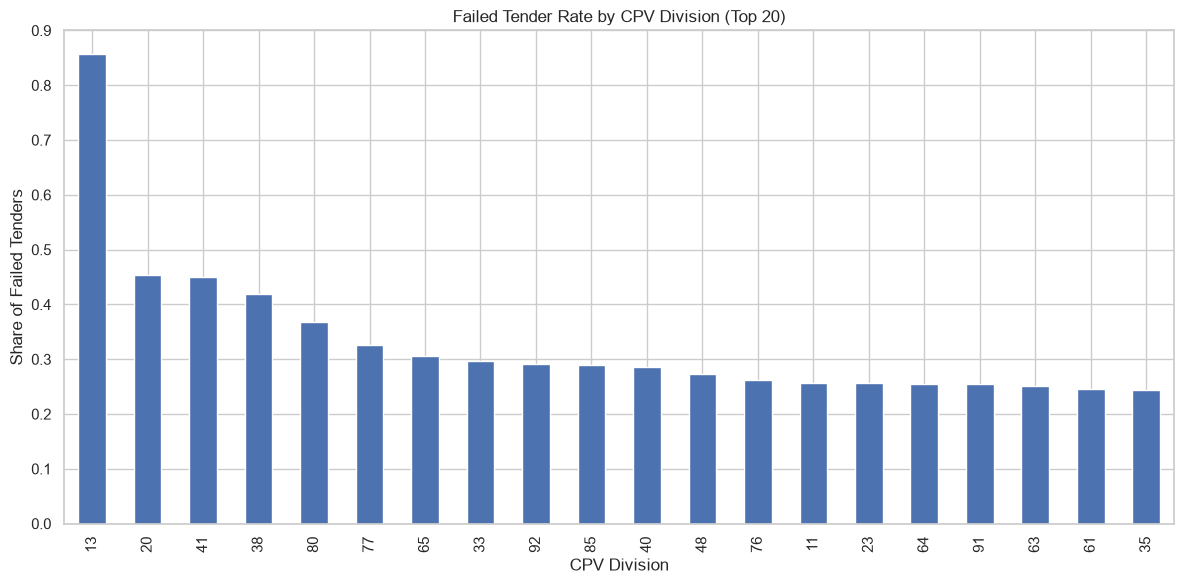

In [9]:
# competition by CPV division

plot_failed_rate_by_cpv_division(df, save=True)

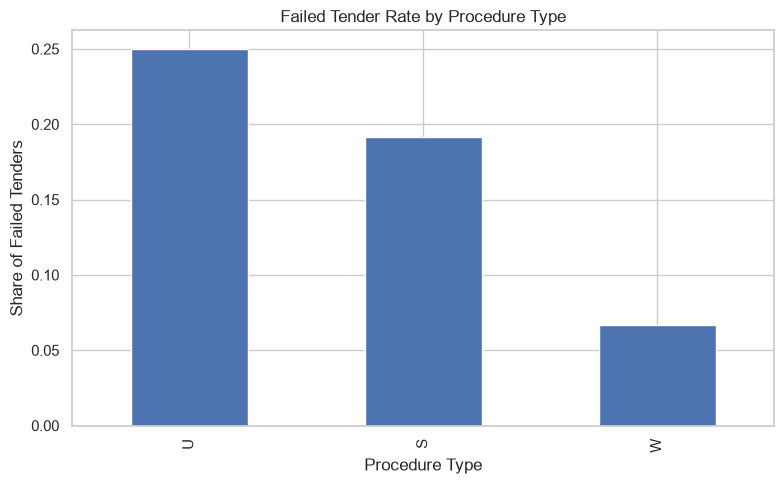

In [10]:
# competition by procedure type

plot_failed_rate_by_procedure(df, save=True)

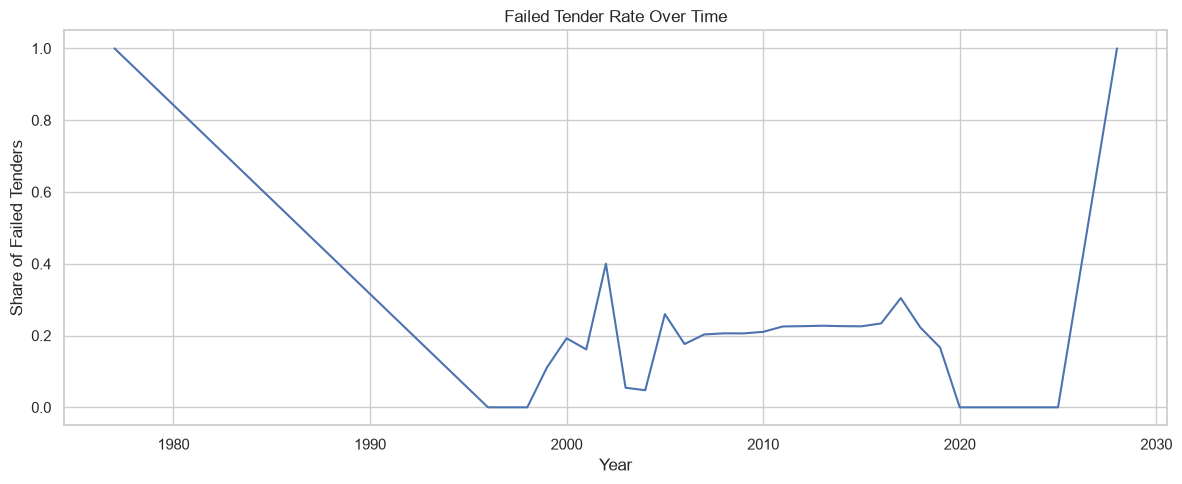

In [11]:
# competition over time

plot_failed_rate_over_time(df, save=True)

In [12]:
df['AWARD_YEAR'].value_counts().sort_index()


AWARD_YEAR
1,977.00         1
1,996.00         2
1,997.00         6
1,998.00         1
1,999.00         9
2,000.00        26
2,001.00        31
2,002.00        15
2,003.00        55
2,004.00        84
2,005.00       231
2,006.00       845
2,007.00     54245
2,008.00    318821
2,009.00    347211
2,010.00    397179
2,011.00    431902
2,012.00    435989
2,013.00    448755
2,014.00    449643
2,015.00    480218
2,016.00    385823
2,017.00        23
2,018.00         9
2,019.00         6
2,020.00         5
2,021.00         5
2,022.00         1
2,025.00         1
2,028.00         1
Name: count, dtype: int64

In [13]:
df = df.drop(columns=["AWARD_YEAR", "AWARD_MONTH"])
df_de = df_de.drop(columns=["AWARD_YEAR", "AWARD_MONTH"])

#### Notes: Key Insights for Modelling Competition
1. Failed tenders are structurally uneven across countries
Countries such as PL, HR, HU, SK consistently show high failure rates, while others remain more stable.
Country remains a strong predictor of competition outcomes.

2. CPV divisions differ dramatically in failure risk
Certain CPV divisions (e.g., 13, 20, 41) show extremely high failure rates, sometimes above 80–90%.
Sector (CPV) is one of the strongest features for predicting tender failure.

3. Procedure type strongly affects failure probability
Procedure type U fails most often, S moderately, W least.
Procedure type is a clear structural driver of competition.

4. Competition categories show a realistic distribution after cleaning
Medium and high competition dominate.
Failed competition stabilizes around ~24–25% after removing corrupted NUMBER_OFFERS outliers.
OFFERS_BIN is stable and meaningful after cleaning.

5. Why failed share dropped from 27.4% to ~25%
A large portion of corrupted records had NUMBER_OFFERS misparsed (e.g., thousands of offers), causing them to be incorrectly classified as failed.
After removing unrealistic values (>100), the failed share reflects real tender outcomes, not noise.

6. Temporal features: YEAR is reliable, AWARD_YEAR is not
AWARD_YEAR and AWARD_MONTH were removed due to corrupted raw dates (e.g., 1977, 2030).
YEAR (based on file year) is consistent and stable.
Only YEAR should be used for modelling.

7. Quarter is useful for modelling, month is not
QUARTER captures seasonal procurement cycles without noise.
MONTH adds unnecessary granularity and increases categorical complexity.
Keep QUARTER; drop MONTH for modelling.

--------------
## Competition Analyse - Germany

--------------

In [14]:
# competition overview

df_de[["IS_FAILED_TENDER", "IS_LOW_COMPETITION", "OFFERS_BIN"]].describe()

,IS_FAILED_TENDER,IS_LOW_COMPETITION
count,"303,349.00","303,349.00"
mean,0.11,0.11
std,0.31,0.31
min,0.00,0.00
25%,0.00,0.00
50%,0.00,0.00
75%,0.00,0.00
max,1.00,1.00


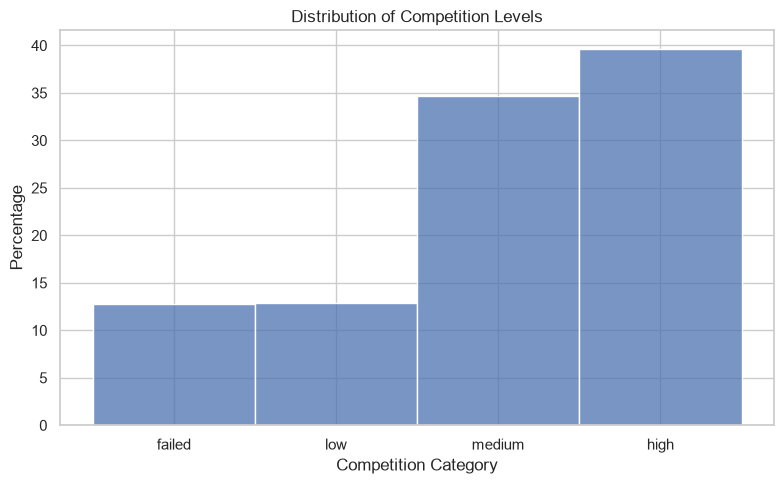

In [15]:
# distribution of competition levels          
plot_offers_bin_distribution(df_de, save=True, path = visual_de)

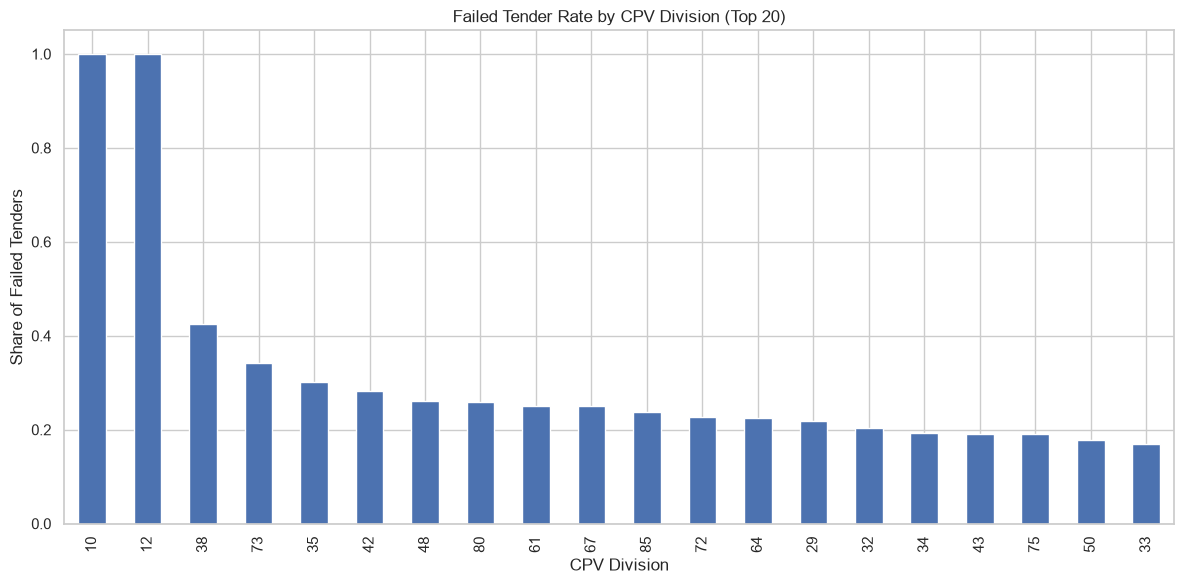

In [16]:
# competition by CPV division

plot_failed_rate_by_cpv_division(df_de, save=True, path = visual_de)

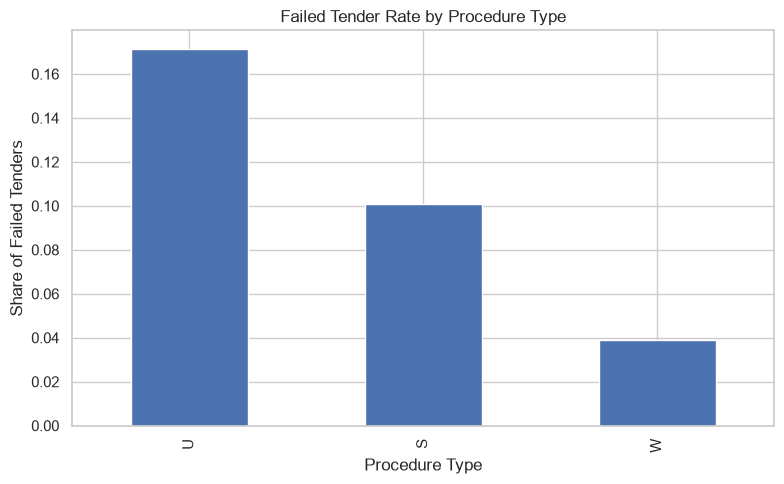

In [17]:
# competition by procedure type

plot_failed_rate_by_procedure(df_de, save=True, path = visual_de)

#### Notes: Key Insights for Modelling Competition — Germany Deep Dive
1. Germany has lower failure rates than EU high‑risk countries
Germany’s failed tender rate is significantly below the EU’s highest-risk countries (PL, HR, HU, SK).
Country-specific behaviour matters — Germany is structurally more competitive.

2. CPV divisions in Germany show strong variation
Some CPV divisions in Germany exhibit elevated failure rates, but none reach the extreme levels seen in EU-wide outliers (e.g., CPV 13 at ~0.9).
Sector effects remain strong, but Germany’s distribution is more balanced.

3. Procedure type patterns are consistent with EU trends
Procedure type U has the highest failure rate, S moderate, W lowest — same structural pattern as EU-wide.
Procedure type remains a reliable predictor within Germany.

4. Competition distribution in Germany is healthier
Germany shows a higher share of medium and high competition compared to the EU average.
Failed competition is lower than EU-wide levels.
Germany’s procurement environment is more stable and competitive.

5. Cleaning NUMBER_OFFERS improved Germany’s data quality
Germany also contained corrupted NUMBER_OFFERS values (hundreds or thousands of offers), though fewer than the EU-wide dataset.
Removing values >100 eliminated noise without removing real failed tenders.
Competition metrics for Germany are now realistic and modelling-ready.

6. Temporal features remain consistent
YEAR is reliable; AWARD_YEAR was removed due to corruption in raw TED data.
QUARTER captures seasonal procurement patterns in Germany without overfitting.
Temporal structure is clean and consistent for modelling.

-------------------------

### FINAL SHAPE & SAVE DATASET

----------------------

In [18]:
# shape dataset
print("EU dataset:", df.shape)
print("DE dataset:", df_de.shape)

EU dataset: (4039906, 41)
DE dataset: (303349, 41)


In [19]:
df.to_pickle("../data/dataset_comp.pkl")
df_de.to_pickle("../data/dataset_de_comp.pkl")